In [5]:
# =========================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =========================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Configuración básica
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid") # Estética profesional para las gráficas

# =========================================================================
# 2. CARGA Y LIMPIEZA INICIAL (Resumen de pasos anteriores)
# =========================================================================

# Cargamos el dataset
df_emp = pd.read_csv("Documentación Inicial/hr.csv")

# Eliminamos duplicados por EmployeeNumber
df_emp = df_emp.drop_duplicates(subset='EmployeeNumber', keep='first')

# Gestión de nulos (Imputación)
def gestionar_nulos(df):
    # Numéricas: Mediana
    for col in ['Age', 'MonthlyIncome', 'JobSatisfaction', 'TrainingTimesLastYear', 'YearsWithCurrManager']:
        df[col] = df[col].fillna(df[col].median())
    # StandardHours: Moda
    if 'StandardHours' in df.columns:
        df['StandardHours'] = df['StandardHours'].fillna(df['StandardHours'].mode()[0])
    # Categóricas: Unknown
    for col in ['BusinessTravel', 'Department', 'EducationField', 'MaritalStatus', 'OverTime']:
        df[col] = df[col].fillna('Unknown')
    return df

df_emp = gestionar_nulos(df_emp)

# Estandarización de textos (Title Case)
def estandarizar_textos(df):
    cols = ['Department', 'EducationField', 'JobRole', 'BusinessTravel', 'Attrition', 'MaritalStatus', 'OverTime']
    for c in cols:
        df[c] = df[c].astype(str).str.strip().str.title()
    return df

df_emp = estandarizar_textos(df_emp)

# Creación de variables derivadas
df_emp['Attrition_flag'] = df_emp['Attrition'].map({'Yes': 1, 'No': 0})
bins = [0, 30, 40, 50, 100]; labels = ['<30', '30-40', '40-50', '>=50']
df_emp['AgeGroup'] = pd.cut(df_emp['Age'], bins=bins, labels=labels, right=False)

# Ajuste de tipos y eliminación de irrelevantes
df_emp = df_emp.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], errors='ignore')



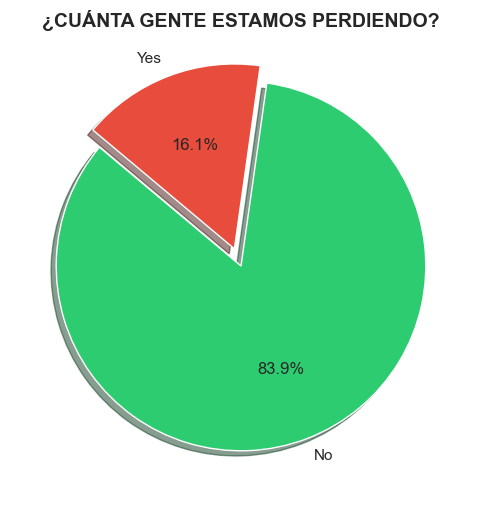

Nota: La tasa del 16.1% supera el umbral saludable del 15%.


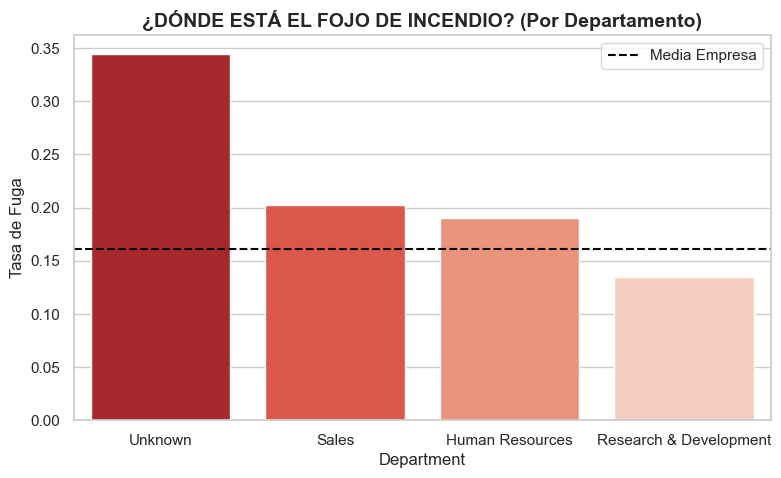

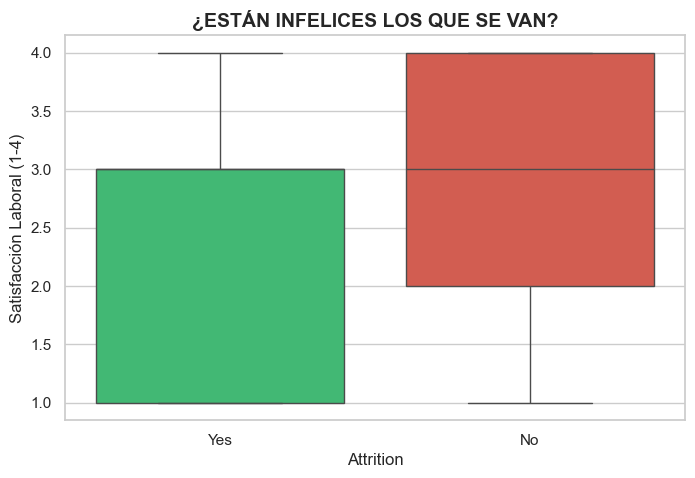

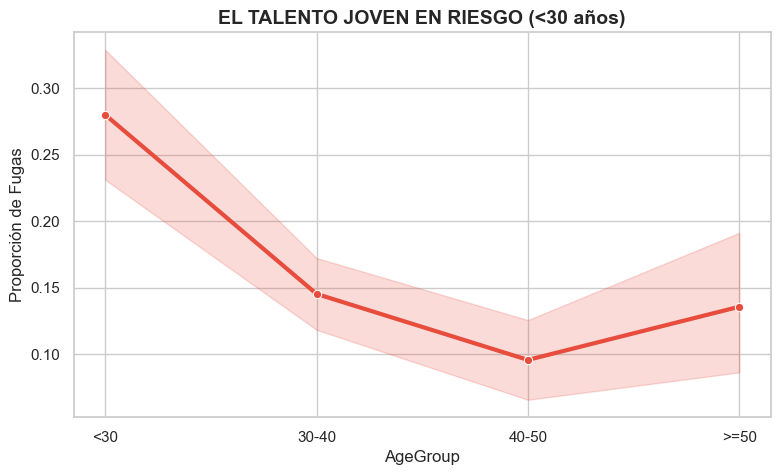

In [4]:
# =========================================================================
# 3. CAPÍTULO 1: STORYTELLING - ¿TENEMOS UN PROBLEMA?
# =========================================================================

# Definimos colores globales para coherencia
colores = ["#2ECC71", "#E74C3C"] # Verde (No se va) / Rojo (Se va)

# --- 1.1 TASA GLOBAL DE ROTACIÓN ---
plt.figure(figsize=(6, 6))
counts = df_emp['Attrition'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
        colors=colores, explode=(0, 0.1), shadow=True)
plt.title('¿CUÁNTA GENTE ESTAMOS PERDIENDO?', fontsize=14, fontweight='bold')
plt.show()

print(f"Nota: La tasa del {df_emp['Attrition_flag'].mean():.1%} supera el umbral saludable del 15%.")

# --- 1.2 ROTACIÓN POR DEPARTAMENTO ---
plt.figure(figsize=(9, 5))
orden_dept = df_emp.groupby('Department')['Attrition_flag'].mean().sort_values(ascending=False).index
sns.barplot(data=df_emp, x='Department', y='Attrition_flag', order=orden_dept, palette='Reds_r', ci=None)
plt.axhline(df_emp['Attrition_flag'].mean(), color='black', linestyle='--', label='Media Empresa')
plt.title('¿DÓNDE ESTÁ EL FOJO DE INCENDIO? (Por Departamento)', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Fuga')
plt.legend()
plt.show()

# --- 1.3 SATISFACCIÓN Y FUGA ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_emp, x='Attrition', y='JobSatisfaction', palette=colores)
plt.title('¿ESTÁN INFELICES LOS QUE SE VAN?', fontsize=14, fontweight='bold')
plt.ylabel('Satisfacción Laboral (1-4)')
plt.show()

# --- 1.4 EL RIESGO GENERACIONAL ---
plt.figure(figsize=(9, 5))
sns.lineplot(data=df_emp, x='AgeGroup', y='Attrition_flag', marker='o', color='#E74C3C', linewidth=3)
plt.title('EL TALENTO JOVEN EN RIESGO (<30 años)', fontsize=14, fontweight='bold')
plt.ylabel('Proporción de Fugas')
plt.show()